In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [3]:
data = pd.read_csv('Marketing-Customer-Value-Analysis.csv')
data.head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


### EDA

In [3]:
data.isnull().sum()

Customer                         0
State                            0
Customer Lifetime Value          0
Response                         0
Coverage                         0
Education                        0
Effective To Date                0
EmploymentStatus                 0
Gender                           0
Income                           0
Location Code                    0
Marital Status                   0
Monthly Premium Auto             0
Months Since Last Claim          0
Months Since Policy Inception    0
Number of Open Complaints        0
Number of Policies               0
Policy Type                      0
Policy                           0
Renew Offer Type                 0
Sales Channel                    0
Total Claim Amount               0
Vehicle Class                    0
Vehicle Size                     0
dtype: int64

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   str    
 1   State                          9134 non-null   str    
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   str    
 4   Coverage                       9134 non-null   str    
 5   Education                      9134 non-null   str    
 6   Effective To Date              9134 non-null   str    
 7   EmploymentStatus               9134 non-null   str    
 8   Gender                         9134 non-null   str    
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   str    
 11  Marital Status                 9134 non-null   str    
 12  Monthly Premium Auto           9134 non-null   int64  
 13 

In [4]:
data.drop(["Customer"], axis=1)

,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,Location Code,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,Suburban,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,Suburban,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,Suburban,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,Suburban,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,Rural,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,California,23405.987980,No,Basic,Bachelor,2/10/11,Employed,M,71941,Urban,...,89,0,2,Personal Auto,Personal L1,Offer2,Web,198.234764,Four-Door Car,Medsize
9130,California,3096.511217,Yes,Extended,College,2/12/11,Employed,F,21604,Suburban,...,28,0,1,Corporate Auto,Corporate L3,Offer1,Branch,379.200000,Four-Door Car,Medsize
9131,California,8163.890428,No,Extended,Bachelor,2/6/11,Unemployed,M,0,Suburban,...,37,3,2,Corporate Auto,Corporate L2,Offer1,Branch,790.784983,Four-Door Car,Medsize
9132,California,7524.442436,No,Extended,College,2/3/11,Employed,M,21941,Suburban,...,3,0,3,Personal Auto,Personal L2,Offer3,Branch,691.200000,Four-Door Car,Large


In [6]:
data["Customer Lifetime Value"].describe()

count     9134.000000
mean      8004.940475
std       6870.967608
min       1898.007675
25%       3994.251794
50%       5780.182197
75%       8962.167041
max      83325.381190
Name: Customer Lifetime Value, dtype: float64

**Основные метрики:**
*   **count** — количество непустых значений (9134 клиента)
*   **mean** — среднее значение (~8005)
*   **std** — стандартное отклонение (~6871). Показывает, насколько сильно значения в среднем отклоняются от среднего.

**Квартили (распределение данных):**
*   **min** — минимальное значение (~1898)
*   **25%** — первый квартиль (~3994). 25% клиентов имеют значение ниже этого порога.
*   **50%** — медиана (~5780). Половина клиентов имеет значение ниже, половина — выше этой суммы.
*   **75%** — третий квартиль (~8962). 75% клиентов имеют значение ниже этого порога.
*   **max** — максимальное значение (~83325)

**Результаты:**
*   **Сильный перекос данных:** Среднее (8005) значительно выше медианы (5780). Это говорит о том, что распределение **правостороннее** — есть небольшое количество клиентов с очень высокой пожизненной ценностью (см. max), которые "тянут" среднее вверх.
*   **Большой разброс:** От 1898 до 83325 при стандартном отклонении 6871.

**Вкратце:** Обычный клиент "стоит" около 5000-9000, но есть редкие клиенты, которые приносят десятки тысяч, из-за чего средний чек по всем клиентам поднимается до 8000.

<Axes: xlabel='Customer Lifetime Value', ylabel='Count'>

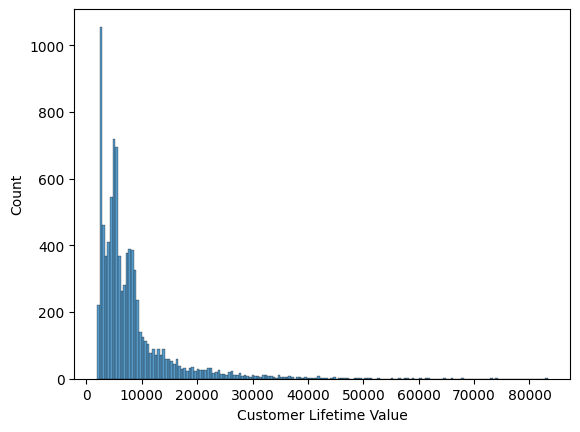

In [7]:

sns.histplot(data["Customer Lifetime Value"]) # Видим что есть правосторонний скос.

### Preprocessing

In [8]:
print(data["Effective To Date"].head())

0    2/24/11
1    1/31/11
2    2/19/11
3    1/20/11
4     2/3/11
Name: Effective To Date, dtype: str


In [5]:
data["Effective To Date"] = pd.to_datetime(data["Effective To Date"])

data["month"] = data["Effective To Date"].dt.month
data["day"] = data["Effective To Date"].dt.day

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include="object"):
    data[col] = le.fit_transform(data[col])

<Axes: >

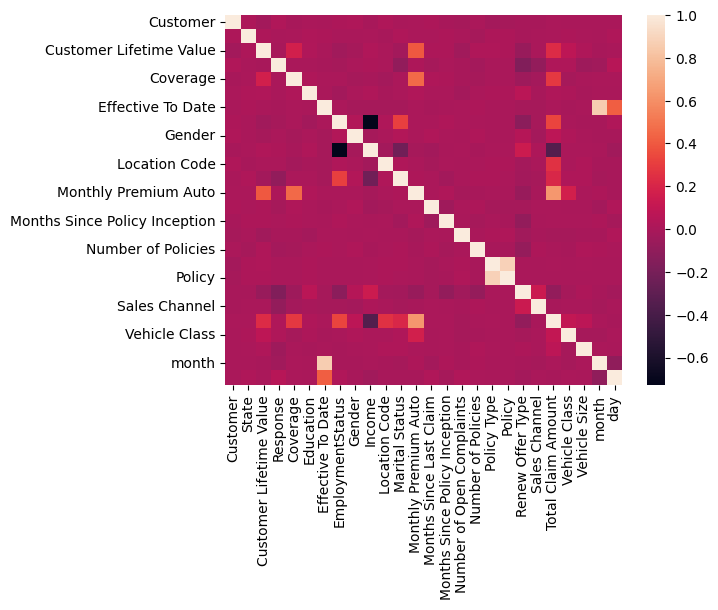

In [7]:
corr = data.corr()
sns.heatmap(corr)
# print(corr)

In [ ]:
# corr = data.corr(numeric_only=True)["Customer Lifetime Value"].sort_values(ascending=False)
# sns.barplot(с)

По результатам корреляции видим, что категория "Monthly Premium Auto" коррелирует с "Total Claim Amount". 
Также категория Policy коллерируется с Policy Type.

<Axes: >

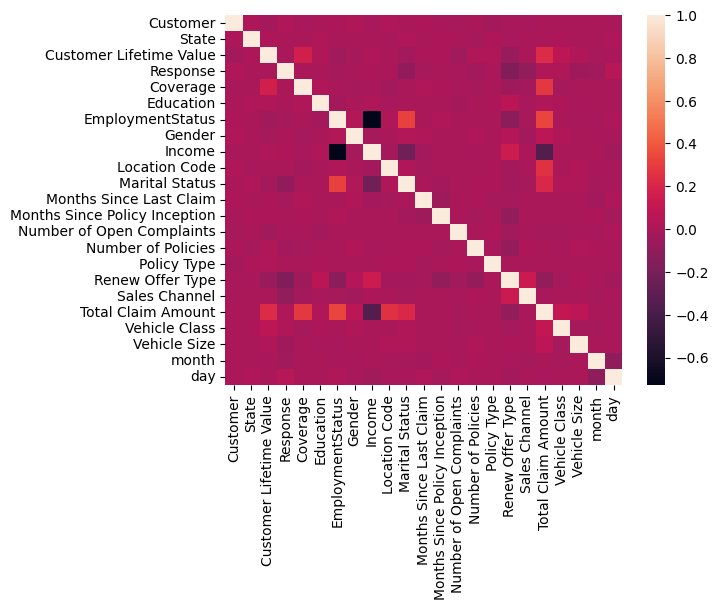

In [ ]:
data_after_rr = data.drop(["Monthly Premium Auto", "Policy", "Effective To Date"], axis=1)
corr_after_rr = data_after_rr.corr()
sns.heatmap(corr_after_rr)

In [27]:
def show_cat_dependencies(data, columns):
    for col in columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=col, y="Customer Lifetime Value", data=data)
        plt.title(f'Зависимость CLV от {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


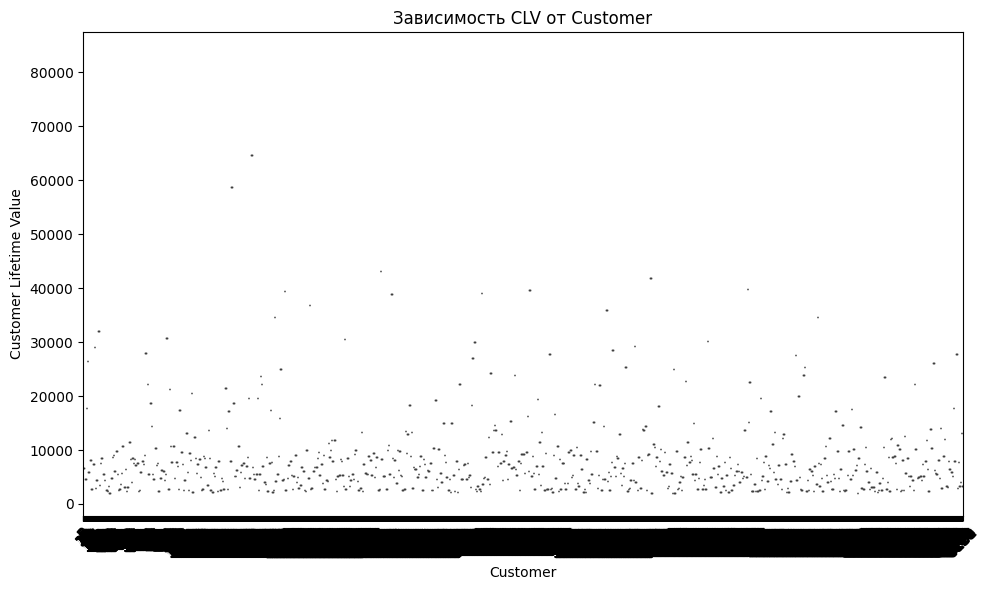

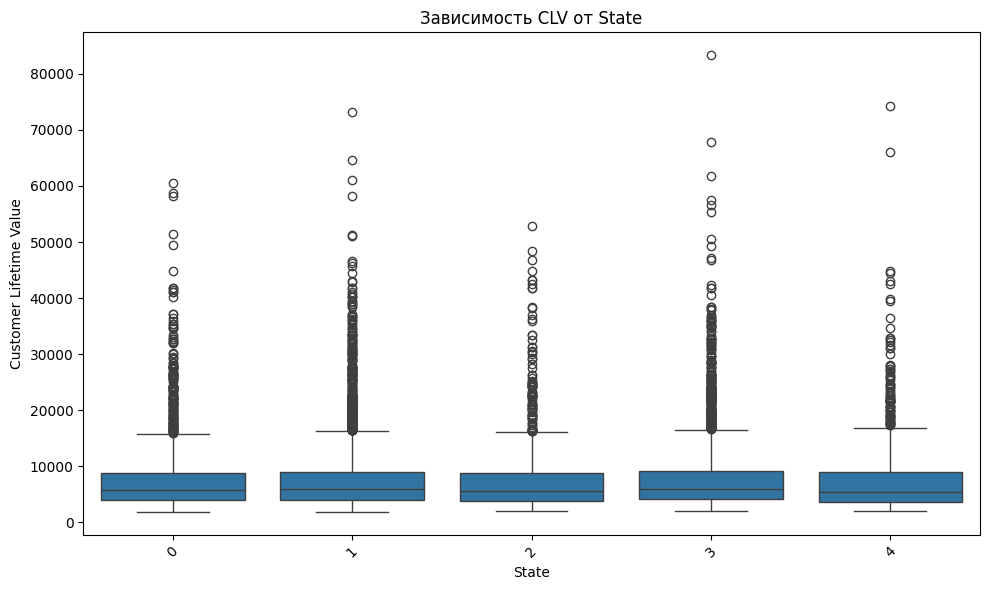

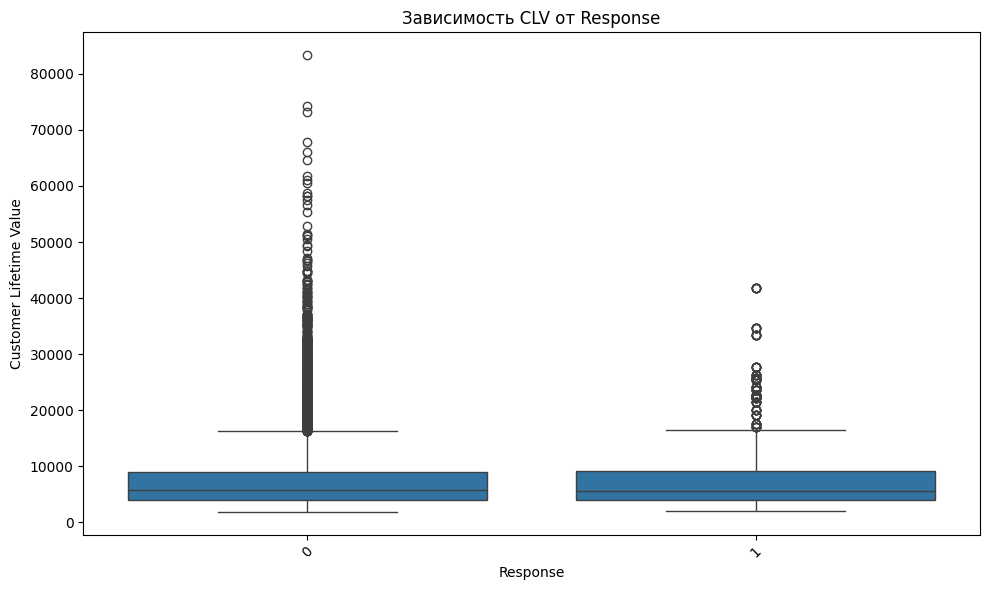

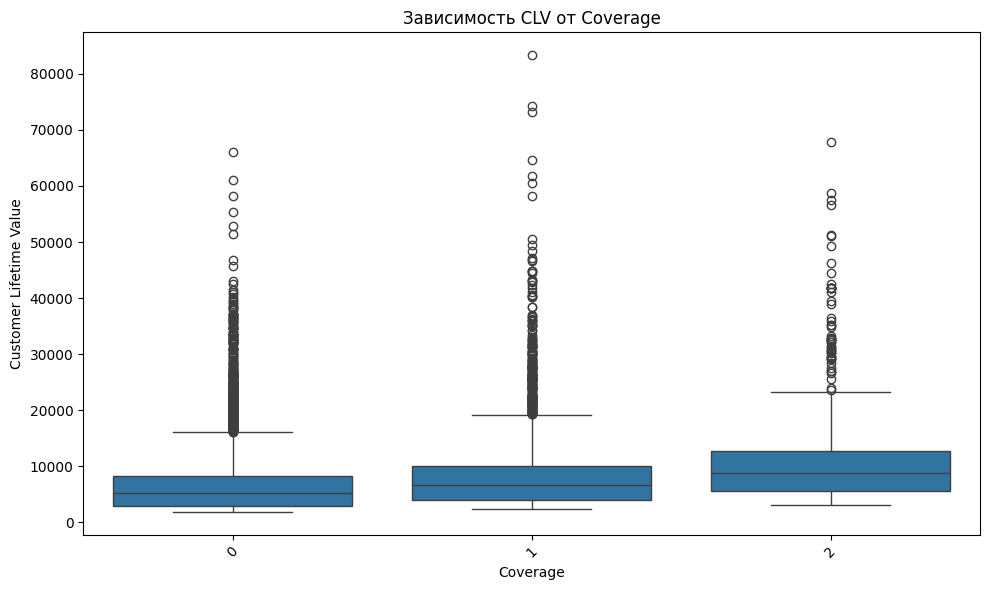

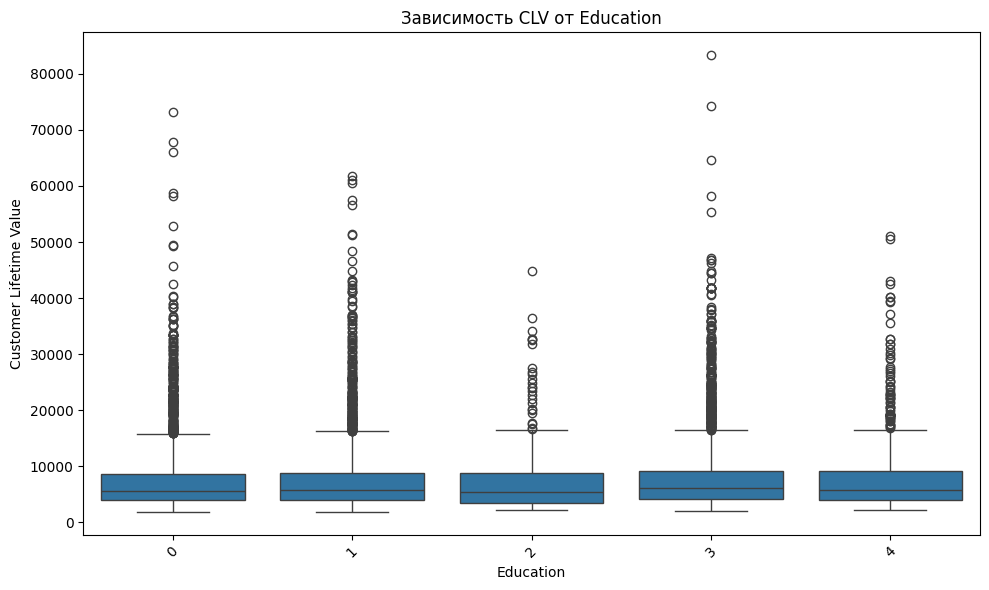

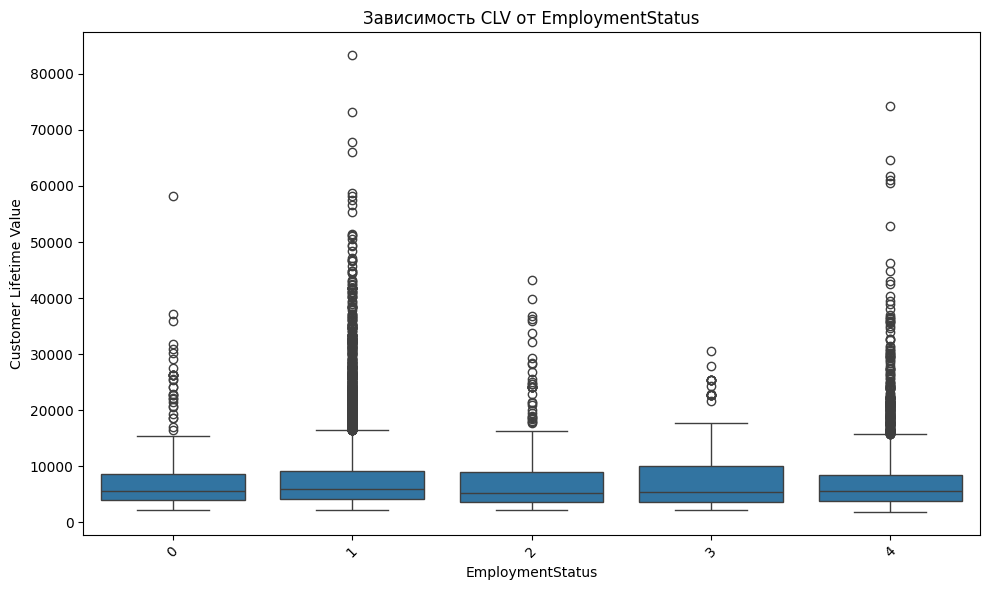

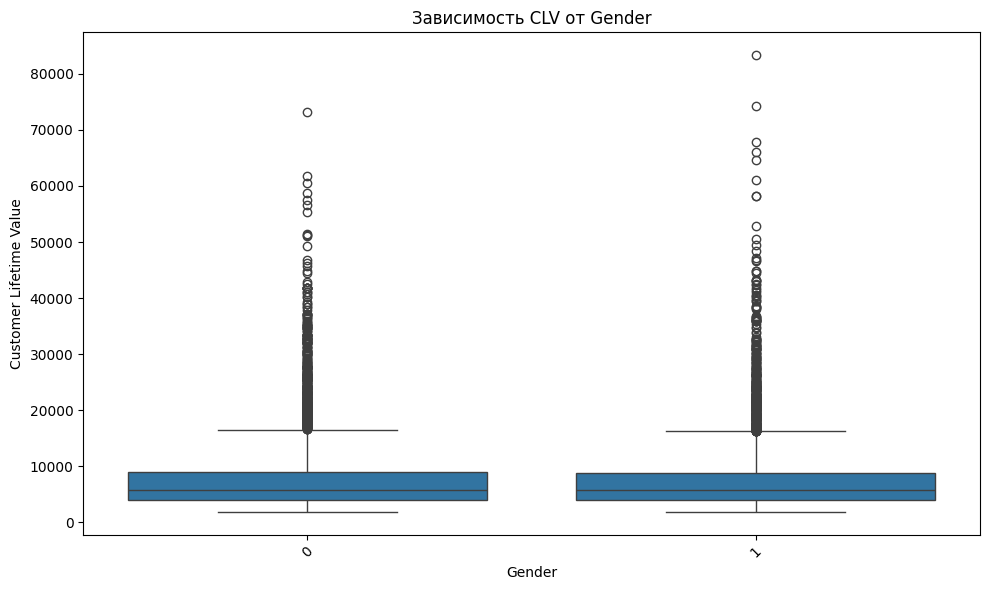

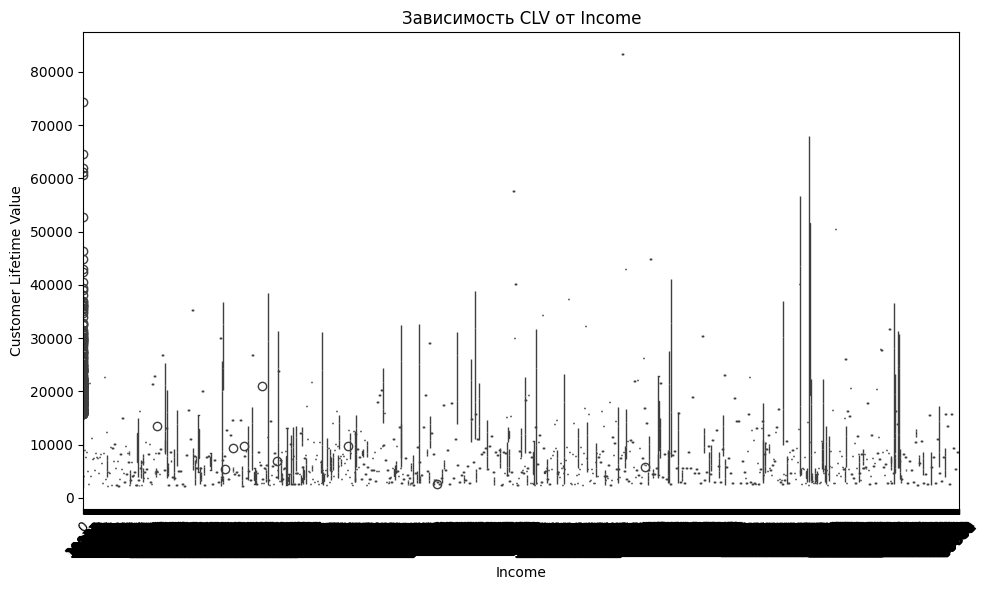

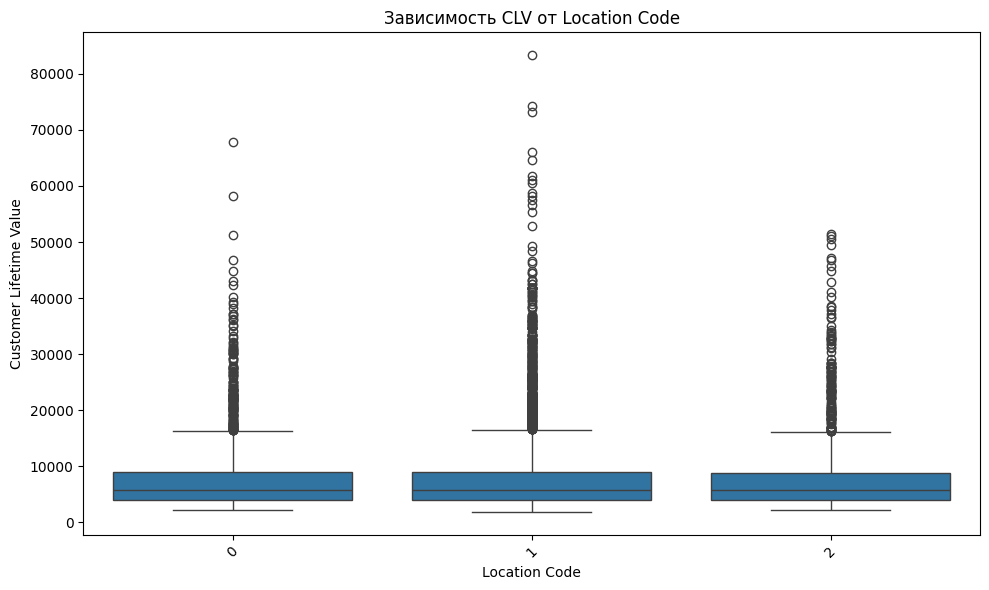

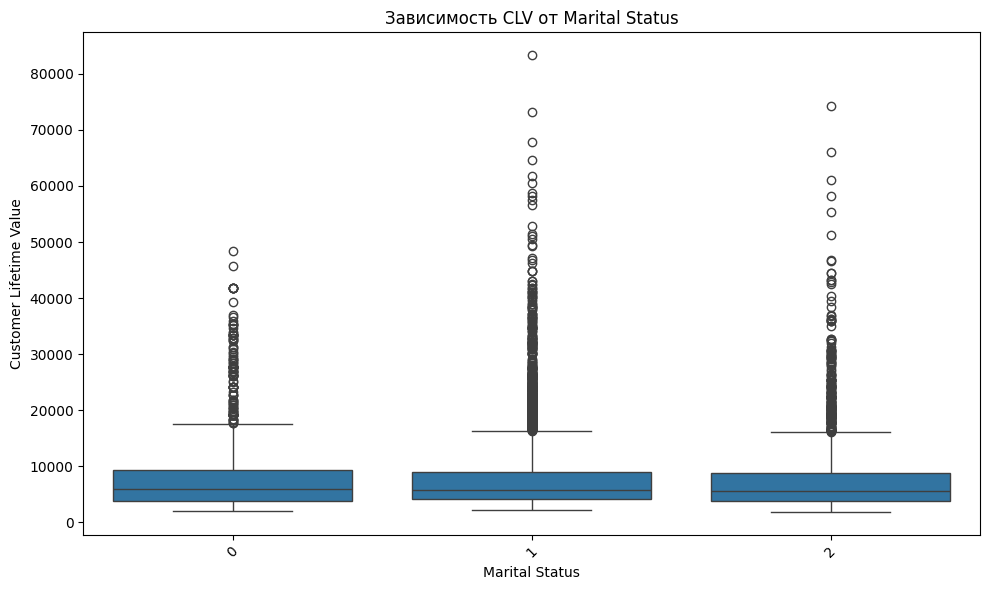

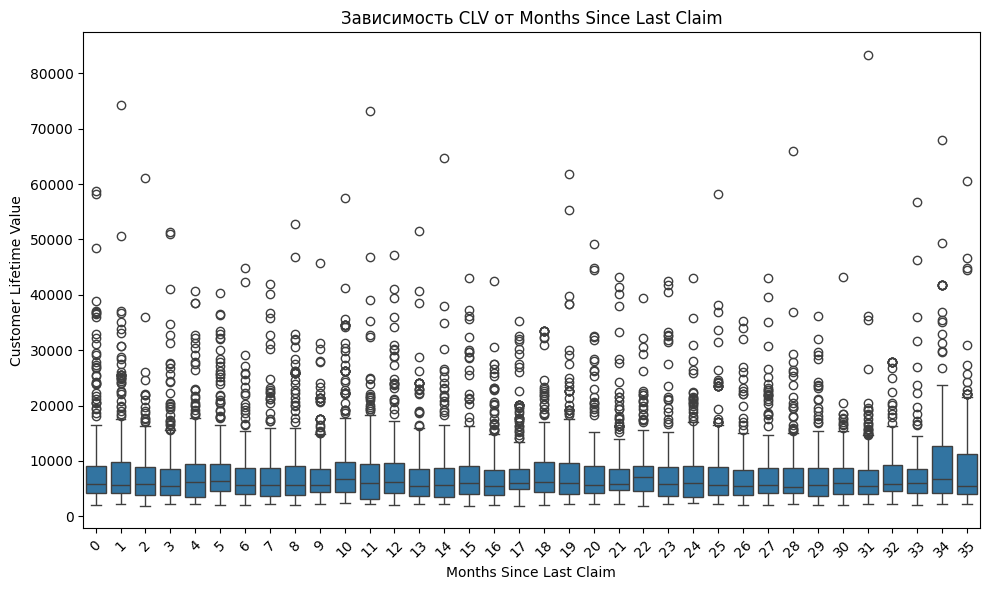

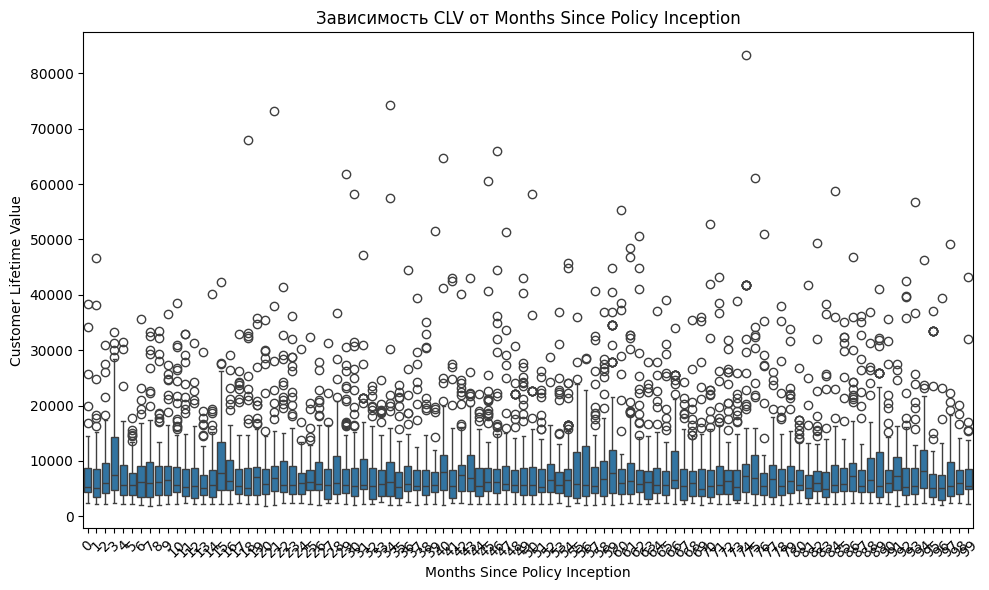

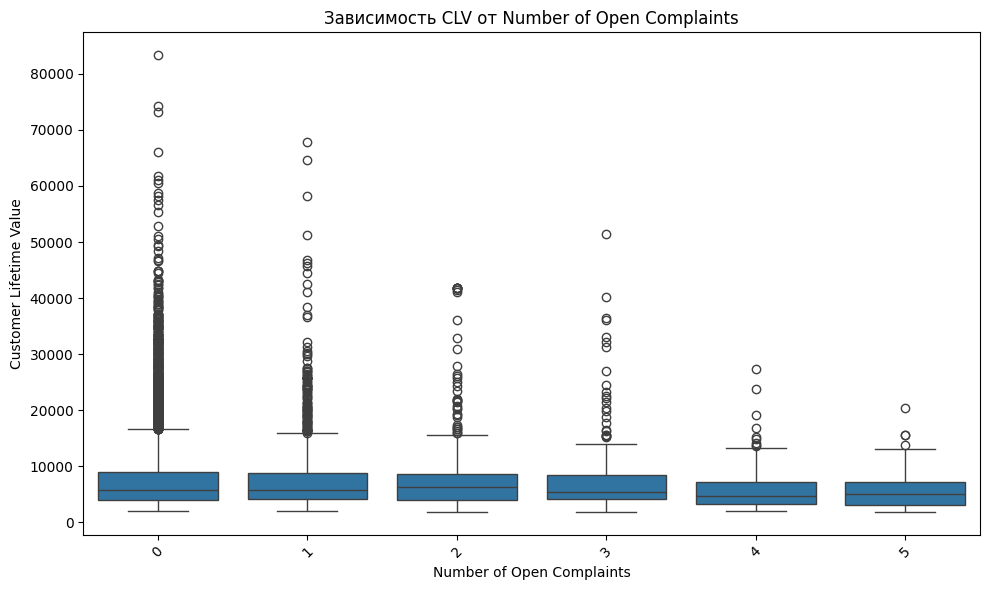

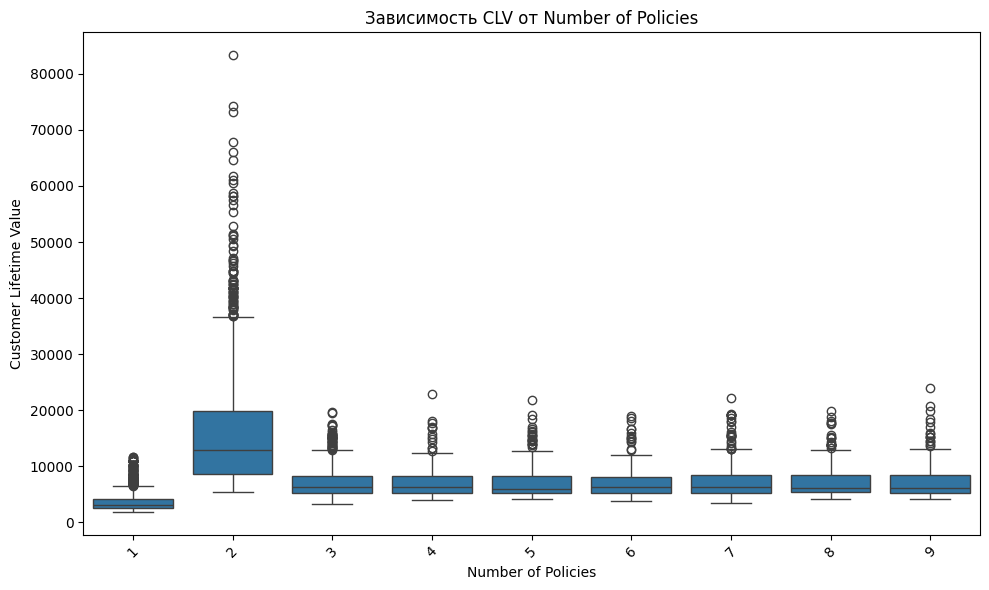

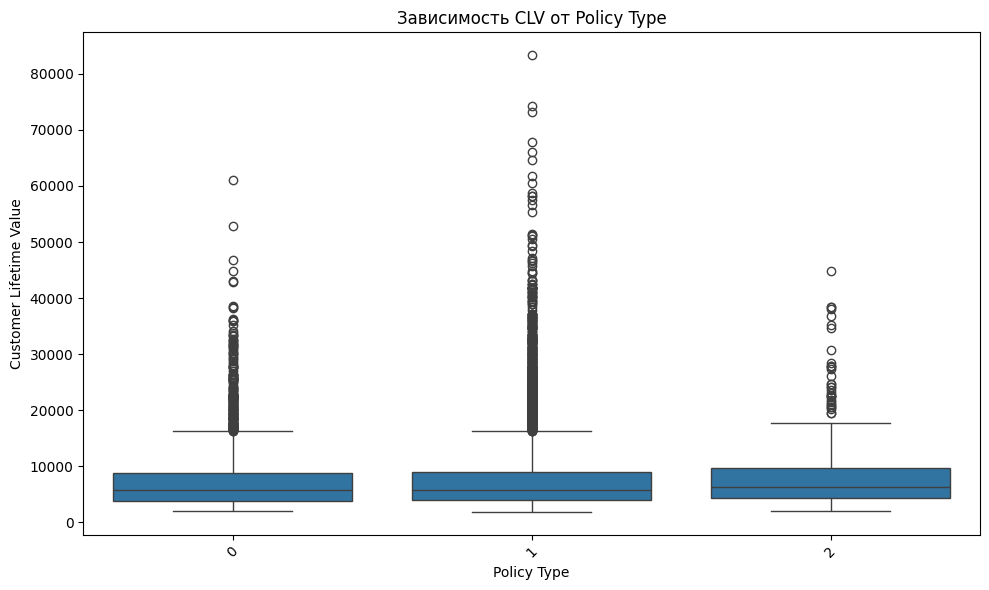

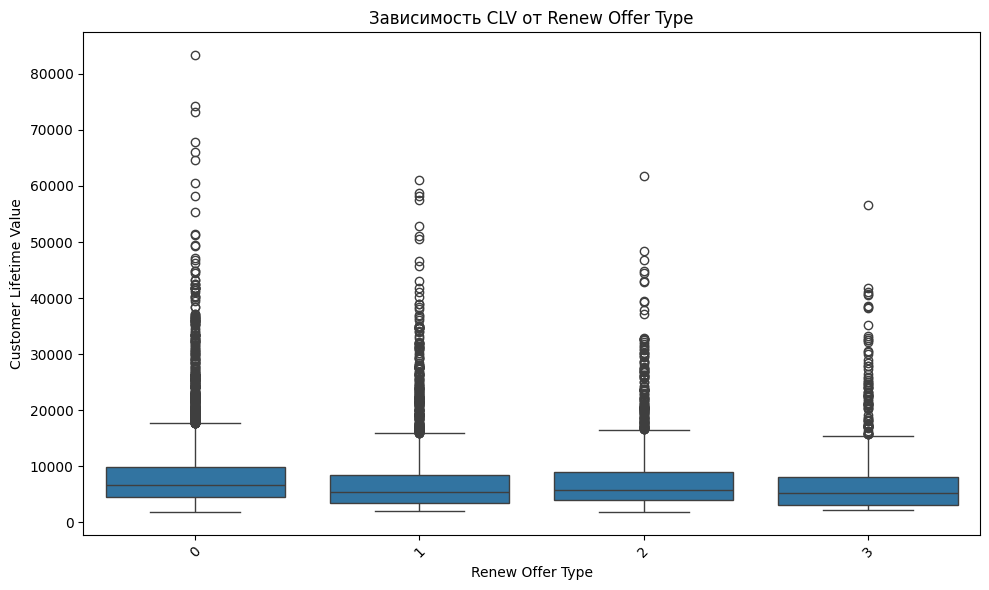

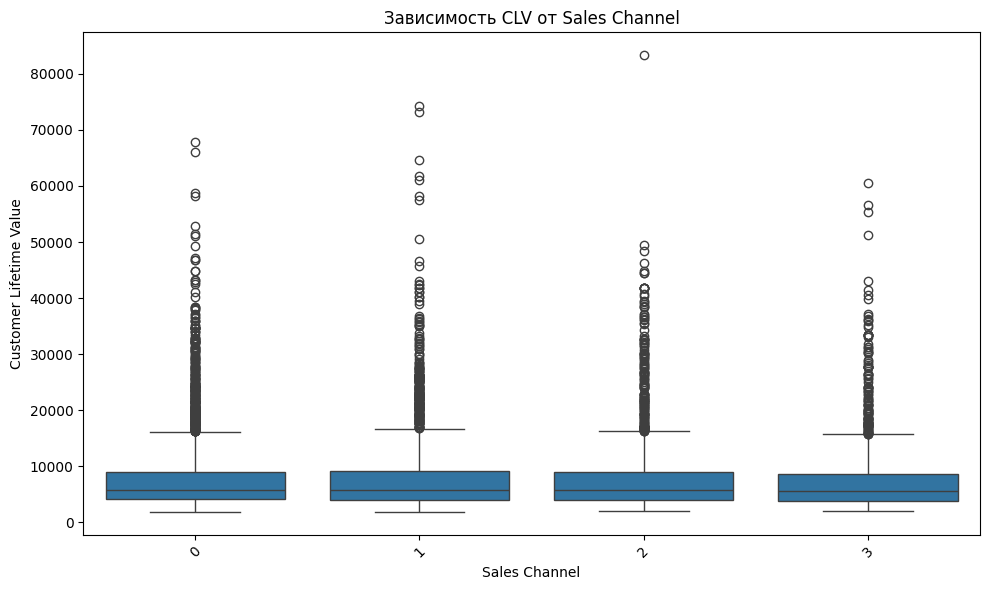

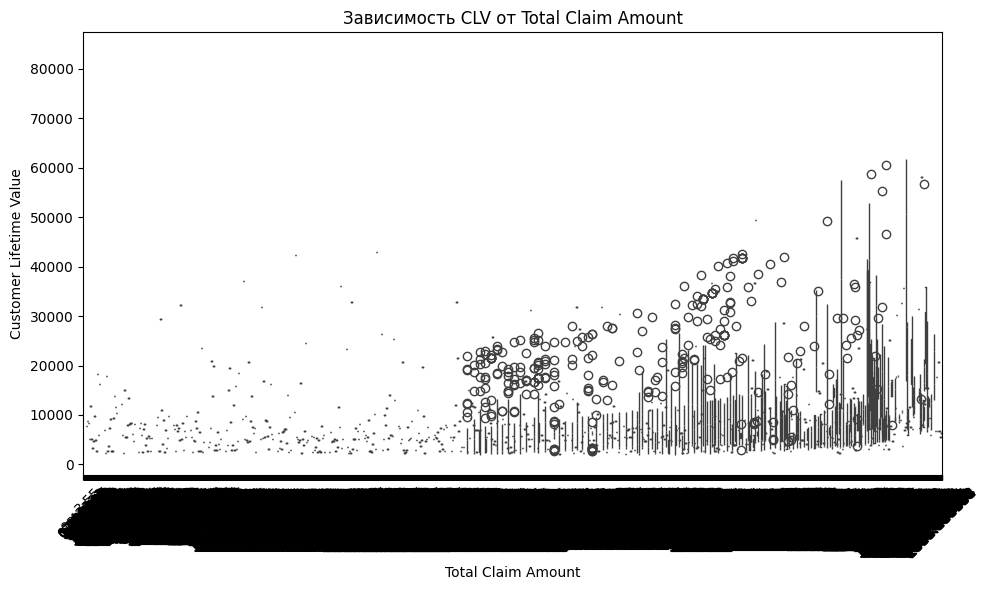

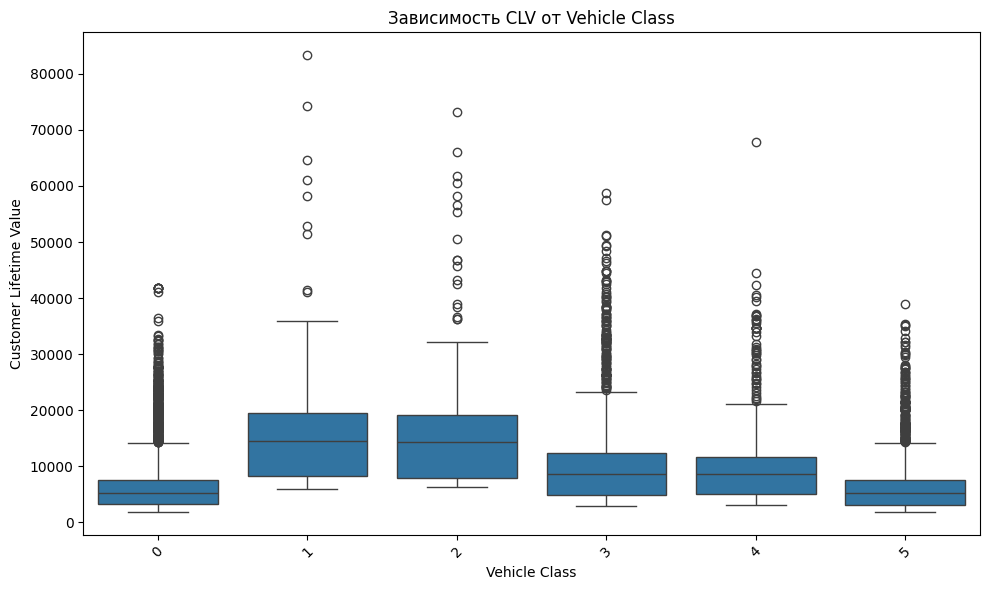

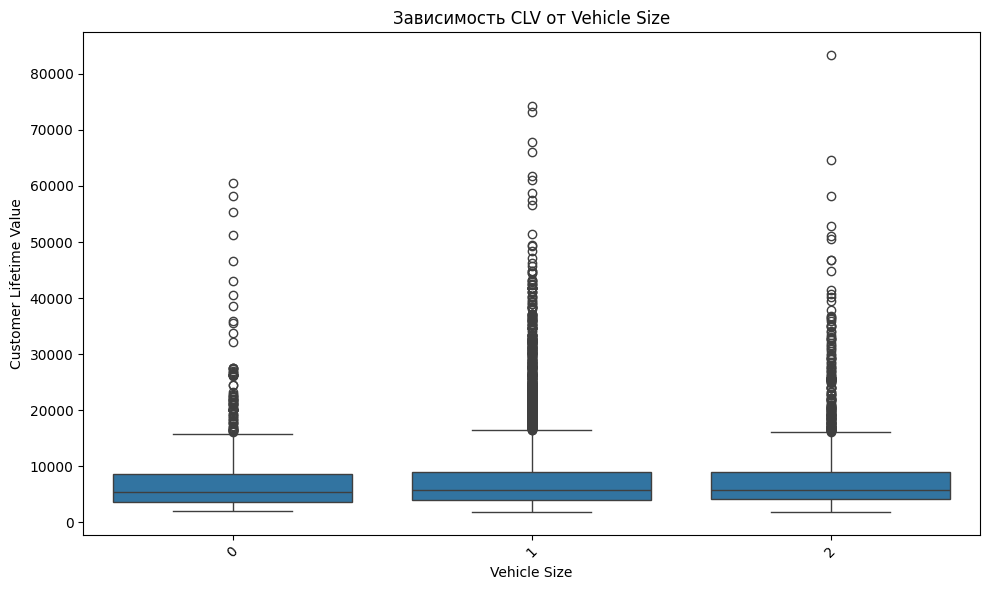

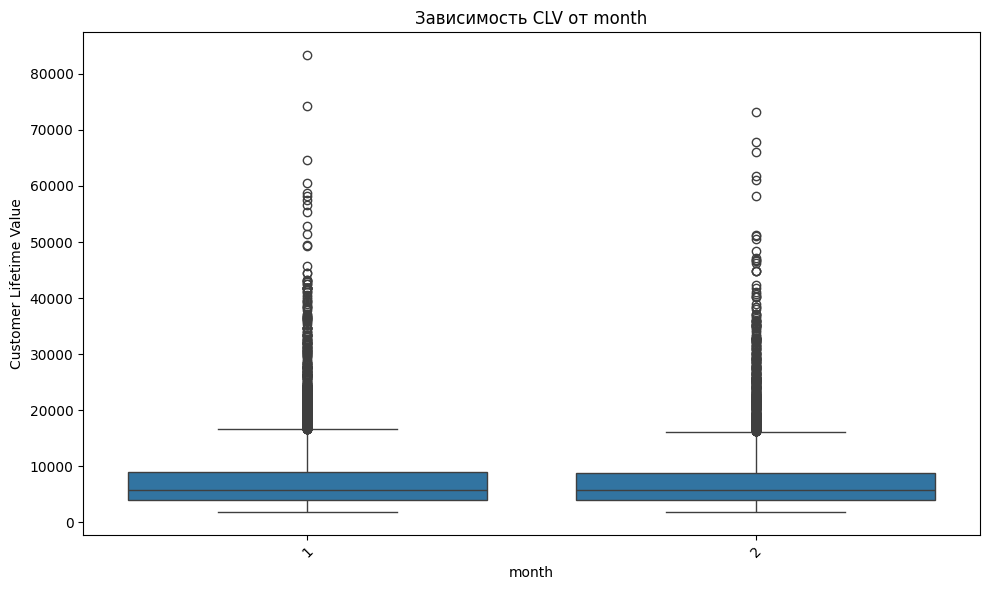

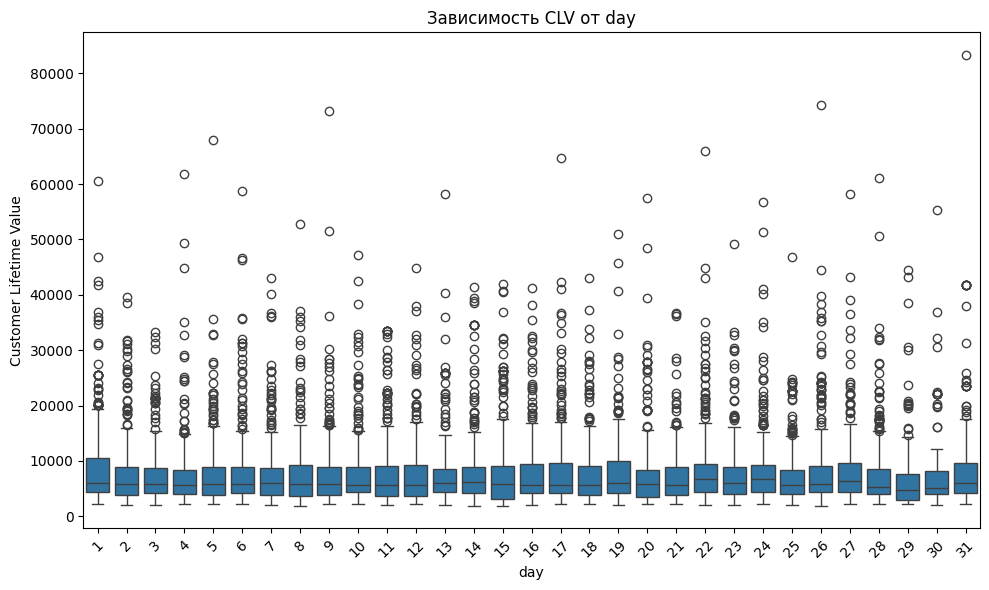

In [28]:
data_rr_clv = data_after_rr.drop(["Customer Lifetime Value"], axis=1)
show_cat_dependencies(data_after_rr, data_rr_clv.columns.tolist())


In [29]:
data_cat_rr = data_after_rr.drop(["Vehicle Size", "Policy Type", "Sales Channel", "Marital Status", "Location Code", "Gender", "Response", "State"], axis=1)

In [ ]:
# show_cat_dependencies(data_after_rr, data_cat_rr.columns.tolist())

In [30]:
data_cat_rr.columns
# data_after_rr.columns

Index(['Customer', 'Customer Lifetime Value', 'Coverage', 'Education',
       'EmploymentStatus', 'Income', 'Months Since Last Claim',
       'Months Since Policy Inception', 'Number of Open Complaints',
       'Number of Policies', 'Renew Offer Type', 'Total Claim Amount',
       'Vehicle Class', 'month', 'day'],
      dtype='str')

In [31]:
from sklearn.model_selection import train_test_split

X = data_cat_rr.drop(["Customer Lifetime Value"], axis=1)
y = data_cat_rr["Customer Lifetime Value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#x - 9134 rows × 14 columns
y

### BOOSTING

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [ ]:
def Anssamble(X_train, X_test, y_train, y_test):
    models = [GradientBoostingRegressor(),
              XGBRegressor(
                  n_estimators=300,
                  learning_rate=0.1,
                  max_depth=5),
              LGBMRegressor(
                  n_estimators=300,
                  learning_rate=0.1,
                  verbose=0
              ),
              CatBoostRegressor(
                  iterations=300,
                  learning_rate=0.1,
                  depth=6,
                  verbose=0
              )]
    
    # RMSE function
    def rmse_r2(y_true, y_pred) -> str:
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        return f"R2 = {r2:.2f}, RMSE = {rmse:.4f}"
    
    log1_y_train = np.log1p(y_train)
    log1_y_test = np.log1p(y_test)

    results_model = []
    results_metrics = []

    for model in models:
        model.fit(X_train, log1_y_train)
        predict = model.predict(X_test)
        metrics = rmse_r2(log1_y_test, predict)
        results_model.append(model.__class__.__name__)
        results_metrics.append(metrics)
        
        
    results = pd.DataFrame({
        "Model": results_model,
        "R2/RMSE_score": results_metrics
    })

    return results

In [51]:
Anssamble(X_train, X_test, y_train, y_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines


,Model,R2/RMSE_score
0,GradientBoostingRegressor,"R2 = 0.89, RMSE = 0.2166"
1,XGBRegressor,"R2 = 0.90, RMSE = 0.2085"
2,LGBMRegressor,"R2 = 0.90, RMSE = 0.2120"
3,CatBoostRegressor,"R2 = 0.90, RMSE = 0.2065"
